# Reward High/Low Classification — Whole-Brain + ROI Group Results

LinearSVC, leave-one-run-out CV, binary target = high (`first_stim_value` >= 4) vs.
low (<= 2) reward level of the first stimulus; the middle level-3 trials are dropped
(~25% of trials) as an ambiguous "neither" case — see `run_qvalue_classification.py`.
Chance = 50%. Four masks: whole-brain, visual cortex (Harvard-Oxford), vmPFC and
striatum (Bartra et al. 2013 meta-analytic ROIs).

This is the simpler counterpart to `run_qvalue_decoding.py`'s continuous regression —
same recipe as the validated stimulus-category decoder (`decoding_results.ipynb`), just
with a binary reward split instead of a 4-way category label. Deliberately sidesteps the
between-run `LeaveOneGroupOut` CV artifact documented in `qvalue_decoding_results.ipynb`
(a degenerate classifier falls back to chance accuracy on a balanced held-out run rather
than producing a systematically *signed* error the way a collapsed regression does).

**Two feature variants per mask** — see status note below: `accuracy_run_demeaned` (the
original) and `accuracy_run_cat_demeaned` (a category-confound control). The latter is
treated as primary throughout this notebook.

**Status (2026-08-07):** 58/59 subjects (`sub-46` absent from the BBT — flagged in
`qvalue_decoding_results.ipynb`, not resolved here).

**Category confound check.** Checked empirically across all 58 subjects: a chi-square
test of stimulus category vs. the low/high split gives p in the 1e-15 to 1e-22 range for
*every single subject* — most categories are entirely low or entirely high for a given
subject (not a tendency, a near-total split), because reward level is tied to a fixed
slot and, within a subject, whole categories tend to land on one side of that slot's
value tier. Since category decodes very well from visual cortex/whole-brain (see
`decoding_results.ipynb`), a classifier could hit high "reward" accuracy purely by
re-detecting category, with zero real value-coding signal.

The fix: every mask also gets a (run x category)-demeaned feature variant (subtract each
run/category cell's own per-voxel mean, leakage-safe, uses only known group membership,
never the label) on top of the run-only demeaning already used for the CV-artifact fix.
**Result: the group effect survives, largely intact** — wholebrain drops 55.8%→54.9%,
visual cortex 63.1%→61.5%, both remaining highly significant (p=4.2e-08 and p=5.3e-16).
So while the category confound is real and severe at the single-trial-structure level,
it is *not* the primary driver of the reward decode.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/decoding")
TAG = "reward"   # filename tag for target_col='first_stim_value' (see run_qvalue_classification.py)
MASKS = ["wholebrain", "visualcortex", "vmpfc", "striatum"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "vmpfc": "vmPFC", "striatum": "Striatum"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452",
          "vmpfc": "#55A868", "striatum": "#C44E52"}
CM_LABELS = ["low", "high"]
CHANCE = 0.5
VARIANTS = ["run_demeaned", "run_cat_demeaned"]
PRIMARY = "run_cat_demeaned"   # category-confound-controlled — see status note above

In [2]:
records = []
cms = {mask: {variant: [] for variant in VARIANTS} for mask in MASKS}

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    acc_file = sub_dir / f"sub-{sub_id}_qvalue_classification_{TAG}.csv"
    if not acc_file.exists():
        continue

    summary = pd.read_csv(acc_file)
    summary.insert(0, "subject", sub_id)
    records.append(summary)

    for mask in MASKS:
        for variant in VARIANTS:
            cm_file = sub_dir / f"sub-{sub_id}_qvalue_classification_confusion_{mask}_{variant}_{TAG}.npy"
            if cm_file.exists():
                cms[mask][variant].append(np.load(cm_file))

df = (pd.concat(records, ignore_index=True) if records else pd.DataFrame(
    columns=["subject", "mask", "n_voxels", "accuracy_run_demeaned",
             "accuracy_run_cat_demeaned", "n_trials", "n_low", "n_high"]))
cms = {mask: {variant: (np.stack(v) if v else None) for variant, v in d.items()}
       for mask, d in cms.items()}

n_subjects = df["subject"].nunique()
print(f"{n_subjects} subject(s) loaded, masks: {sorted(df['mask'].unique()) if n_subjects else []}")

58 subject(s) loaded, masks: ['striatum', 'visualcortex', 'vmpfc', 'wholebrain']


## Group accuracy — raw vs. category-confound-controlled

=== accuracy_run_demeaned (original) ===
wholebrain: mean=0.558, t(57)=9.44, p=2.98e-13  ***
visualcortex: mean=0.631, t(57)=20.68, p=3.59e-28  ***
vmpfc: mean=0.498, t(57)=-0.32, p=7.52e-01  ns
striatum: mean=0.505, t(57)=0.87, p=3.88e-01  ns

=== accuracy_run_cat_demeaned (category-confound control, primary) ===
wholebrain: mean=0.549, t(57)=6.32, p=4.20e-08  ***
visualcortex: mean=0.615, t(57)=11.19, p=5.28e-16  ***
vmpfc: mean=0.499, t(57)=-0.20, p=8.39e-01  ns
striatum: mean=0.498, t(57)=-0.35, p=7.27e-01  ns


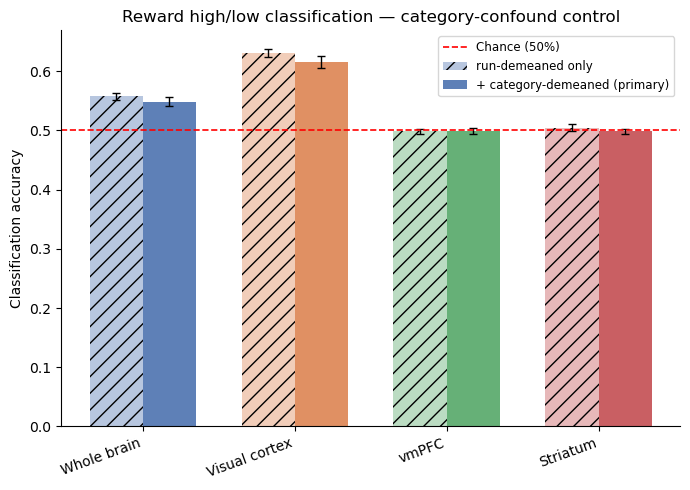

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(MASKS))
w = 0.35

for i, mask in enumerate(MASKS):
    color = COLORS[mask]
    vals_run = df.loc[df["mask"] == mask, "accuracy_run_demeaned"].values
    vals_cat = df.loc[df["mask"] == mask, "accuracy_run_cat_demeaned"].values
    ax.bar(i - w/2, vals_run.mean(), width=w, color=color, alpha=0.4, zorder=2,
           label="run-demeaned only" if i == 0 else None, hatch='//')
    ax.bar(i + w/2, vals_cat.mean(), width=w, color=color, alpha=0.9, zorder=2,
           label="+ category-demeaned (primary)" if i == 0 else None)
    if len(vals_run) > 1:
        ax.errorbar(i - w/2, vals_run.mean(), yerr=vals_run.std()/np.sqrt(len(vals_run)),
                    fmt='none', color='black', capsize=3, linewidth=1)
        ax.errorbar(i + w/2, vals_cat.mean(), yerr=vals_cat.std()/np.sqrt(len(vals_cat)),
                    fmt='none', color='black', capsize=3, linewidth=1)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=20, ha='right')
ax.set_ylabel("Classification accuracy")
ax.set_title("Reward high/low classification — category-confound control")
ax.legend(fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)

print("=== accuracy_run_demeaned (original) ===")
for mask in MASKS:
    vals = df.loc[df["mask"] == mask, "accuracy_run_demeaned"].values
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{mask}: mean={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

print("\n=== accuracy_run_cat_demeaned (category-confound control, primary) ===")
for mask in MASKS:
    vals = df.loc[df["mask"] == mask, "accuracy_run_cat_demeaned"].values
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{mask}: mean={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

plt.tight_layout()
plt.show()

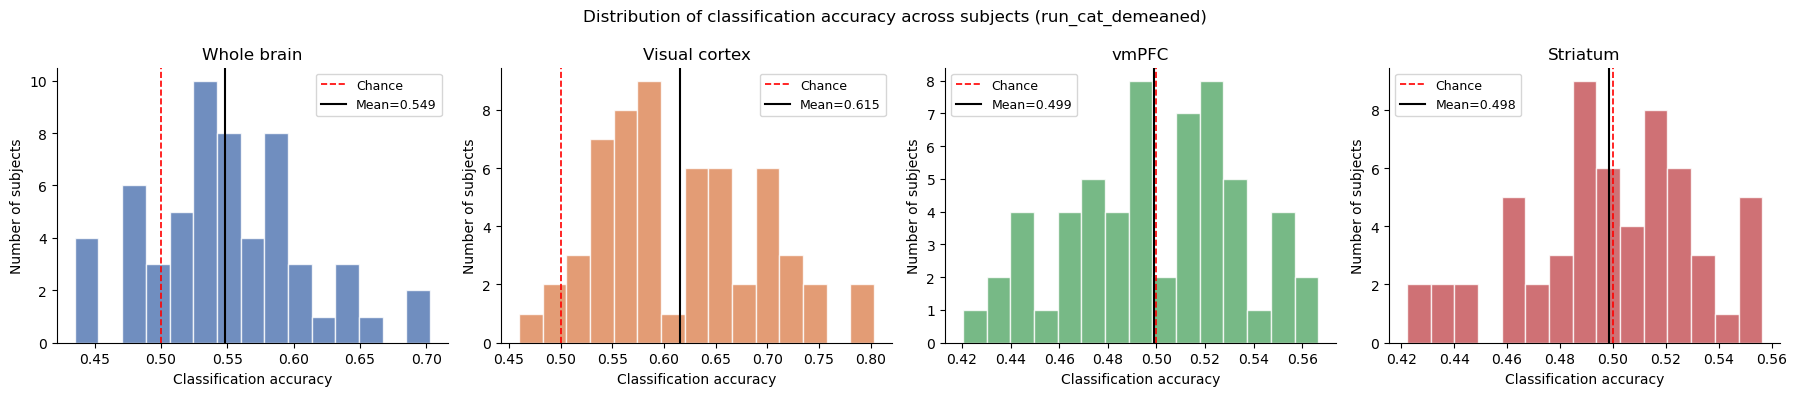

In [4]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4), sharey=False)

for ax, mask in zip(axes, MASKS):
    vals = df.loc[df["mask"] == mask, f"accuracy_{PRIMARY}"].values
    color = COLORS[mask]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance')
    if len(vals):
        ax.axvline(vals.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel("Classification accuracy")
    ax.set_ylabel("Number of subjects")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f"Distribution of classification accuracy across subjects ({PRIMARY})")
plt.tight_layout()
plt.show()

## Confusion matrices (group average, normalized by true class, category-demeaned/primary variant)

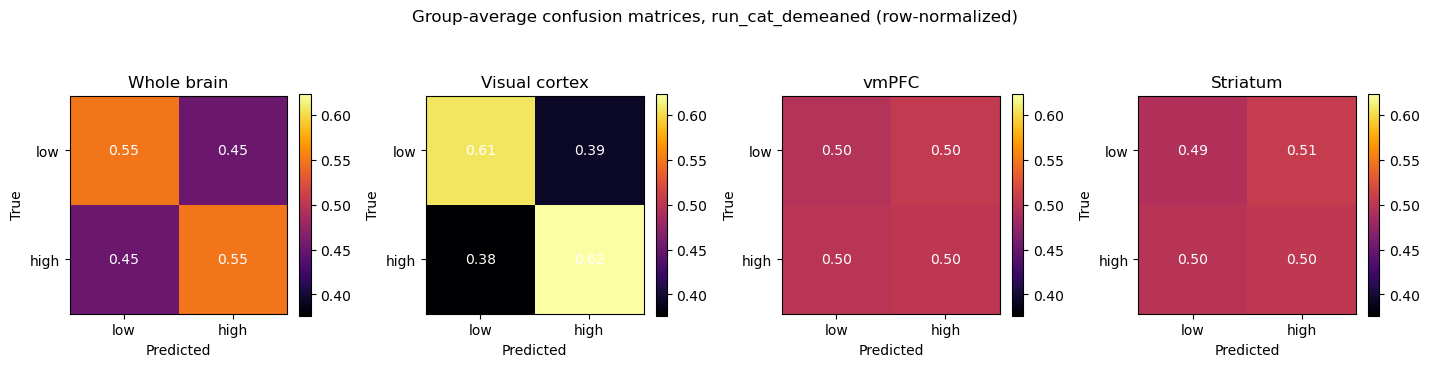

In [5]:
def normalize_cm(cm_stack):
    """Row-normalize each subject's CM, then average."""
    normed = cm_stack.astype(float)
    normed = normed / normed.sum(axis=2, keepdims=True)
    return normed.mean(axis=0)

fig, axes = plt.subplots(1, len(MASKS), figsize=(3.6 * len(MASKS), 3.6))

all_cms = [normalize_cm(cms[mask][PRIMARY]) for mask in MASKS if cms[mask][PRIMARY] is not None]
vmin = min(cm.min() for cm in all_cms)
vmax = max(cm.max() for cm in all_cms)

for ax, mask in zip(axes, MASKS):
    if cms[mask][PRIMARY] is None:
        continue
    cm_norm = normalize_cm(cms[mask][PRIMARY])
    im = ax.imshow(cm_norm, cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(2)); ax.set_yticks(range(2))
    ax.set_xticklabels(CM_LABELS); ax.set_yticklabels(CM_LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(MASK_LABELS[mask])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm_norm[r, c]:.2f}",
                    ha='center', va='center', fontsize=10, color='white')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Group-average confusion matrices, {PRIMARY} (row-normalized)", y=1.02)
plt.tight_layout()
plt.show()

## Individual subject accuracy (category-demeaned/primary variant)

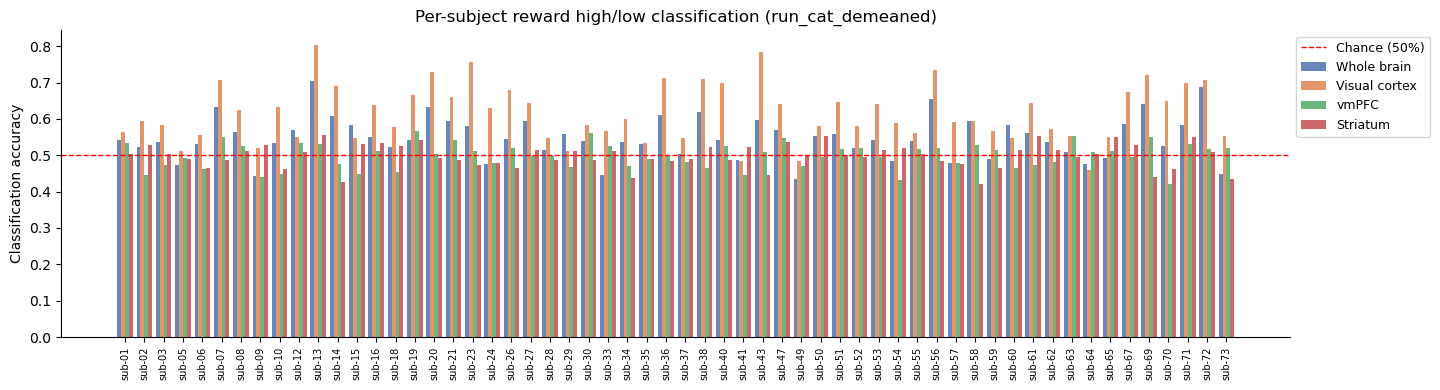

In [6]:
subjects = sorted(df["subject"].unique())
pivot = df.pivot(index="subject", columns="mask", values=f"accuracy_{PRIMARY}").reindex(subjects)

fig, ax = plt.subplots(figsize=(max(14, 0.25 * len(subjects)), 4))
x = np.arange(len(subjects))
n_masks = len(MASKS)
width = 0.8 / n_masks

for i, mask in enumerate(MASKS):
    if mask not in pivot.columns:
        continue
    offset = (i - (n_masks - 1) / 2) * width
    ax.bar(x + offset, pivot[mask], width=width, label=MASK_LABELS[mask], color=COLORS[mask], alpha=0.85)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels([f"sub-{s}" for s in subjects], rotation=90, fontsize=7)
ax.set_ylabel("Classification accuracy")
ax.set_title(f"Per-subject reward high/low classification ({PRIMARY})")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Open question: is the "surviving" signal identity, not value?

**Added 2026-08-17, rescuing a derivation from a since-deleted scratchpad** (see
`session-notes/2026-08-13_feedback-glmsingle-and-cue-redundancy.md`, finding 2, and
`session-notes/2026-08-11_glmsingle-conditions-and-reward-decoding.md`, §3). This
directly challenges the findings-summary interpretation below, so read it first.

The findings summary argues that because the effect survives `(run × category)`
demeaning, it reflects "genuine within-category variance carrying reward information,
not just category re-detection in disguise." That framing implicitly assumes
category-demeaning is enough to separate *value* coding from *identity* coding. It
isn't — here is why, reproduced directly from `bbt.csv` rather than the pipeline's
derived CSVs.

`first_stim_value` is a **deterministic function of stimulus identity**: every
`(subject, first_stim_name)` cell has exactly one reward value, and every subject's
four categories carry the fixed value-pairs `(1,5)`, `(2,3)`, `(2,4)`, `(3,4)` — the two
stimuli within a category never share a value. This classification task drops level-3
trials, so only the `(1,5)` and `(2,4)` categories straddle the low/high split; within
each of those two categories, "low" vs. "high" **is** the individual-stimulus identity
label. Category-demeaning removes the *between*-category mean pattern, but does nothing
to identity, so a classifier that survives it could be doing pure two-way identity
discrimination inside those two categories with zero value coding involved. That also
predicts, without further assumptions, the exact profile seen above: visual cortex
(best at low-level stimulus identity) ≫ whole brain ≫ vmPFC/striatum flat at chance.

In [ ]:
BBT_PATH = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bbt.csv")
bbt = pd.read_csv(BBT_PATH)

# --- Deterministic identity -> value -------------------------------------------------
within_cell_var = (
    bbt.groupby(["sub_id", "first_stim_name"])["first_stim_value"]
    .apply(lambda s: s.var(ddof=0))
)
n_cells = len(within_cell_var)
n_deterministic = int((within_cell_var == 0).sum())
print(f"(subject x stimulus) cells: {n_cells}, with 0 within-cell variance: {n_deterministic}")
assert n_deterministic == n_cells, "identity -> value is no longer deterministic!"

# --- Fixed category value-pairs, every subject ----------------------------------------
cat_pairs = (
    bbt.groupby(["sub_id", "first_stim_cat"])["first_stim_value"]
    .apply(lambda s: tuple(sorted(int(v) for v in s.unique())))
)
print("\nCategory value-pair counts across all (subject x category) cells:")
print(cat_pairs.value_counts())

# --- Which categories straddle the low(<=2)/high(>=4) split used by this task ---------
straddling = {pair for pair in cat_pairs.unique() if min(pair) <= 2 and max(pair) >= 4}
print(f"\nPairs that straddle the low/high split (level-3 dropped): {sorted(straddling)}")
print(
    "-> within those categories, the low/high label is a deterministic re-labelling "
    "of stimulus identity, not an independent value signal."
)


**Status: not yet adjudicated.** The falsification test proposed for this — re-running
the classification demeaning by stimulus identity instead of category — was flagged in
the same follow-up list as likely ill-posed: demeaning by identity removes the value
signal along with everything else, since value has 0 variance conditional on identity
(see derivation above). So that specific test can't distinguish the two hypotheses;
a different design is needed (e.g. restricting to categories/pairs that do *not*
straddle the low/high split, or a searchlight that separately localizes identity- vs.
value-selective voxels). Until that's done, treat the findings-summary interpretation
below ("genuine within-category variance carrying reward information") as unconfirmed.

## Findings summary

n=58 (`sub-46` absent from the BBT).

| Mask | run-demeaned | + category-demeaned (primary) | p (primary) |
|---|---|---|---|
| Whole brain | 0.558 | **0.549** | 4.2e-08 \*\*\* |
| Visual cortex | 0.631 | **0.615** | 5.3e-16 \*\*\* |
| vmPFC | 0.498 | **0.499** | 0.84  ns |
| Striatum | 0.505 | **0.498** | 0.73  ns |

- **The reward decode survives the category-confound control, largely intact.** Despite
  category being essentially deterministic of the low/high split for every single
  subject (chi-square p in the 1e-15 to 1e-22 range — see the status note above),
  surgically removing all category-driven mean-pattern signal only costs ~1–1.6
  percentage points for wholebrain/visual cortex, and both remain overwhelmingly
  significant. So while the confound is real and severe at the trial-structure level,
  it is **not the primary driver** of the reward decode — there's genuine within-category
  variance carrying reward information, not just category re-detection in disguise.
- **vmPFC/striatum are unmoved either way** — chance both before and after the category
  control (0.498→0.499, 0.505→0.498), symmetric spread, no systematic offset. This
  **converges with the regression version's within-run finding** (small, mostly
  borderline-significant negative `r` after removing its own CV artifact): two
  independent analyses now agree there's no reliable reward signal detectable in these
  ROIs at whole-ROI-average resolution.
- **Bottom line:** whole-brain/visual-cortex reward decoding is real, not a category- or
  CV-artifact. vmPFC/striatum remain an open question — consistent with either "no
  reward-value coding here for this task" or "coding exists but is spatially localized
  and a whole-ROI average washes it out" (RidgeCV's near-constant predictions in the
  regression version are circumstantial evidence for the latter). Searchlight is the
  natural next step to distinguish the two, specifically for these two regions.